In [1]:
import numpy as np
import pandas as pd
import plotnine as pn

from plotnine.data import msleep

In [2]:
df = msleep.dropna(subset = "vore")

odf = (df
    .groupby("vore", as_index = False)
    .aggregate(
        mean = ("sleep_total", np.mean),
        sd = ("sleep_total", np.std),
        count = ("sleep_total", np.size)))

In [3]:
odf["se"] = odf["sd"] / np.sqrt(odf["count"])
# 95% confidence
odf["ub2"] = odf["mean"] + 1.96 * odf["se"]
odf["lb2"] = odf["mean"] - 1.96 * odf["se"]
# 68% confidence
odf["ub1"] = odf["mean"] + odf["se"]
odf["lb1"] = odf["mean"] - odf["se"]

In [14]:
df["vore"] = df["vore"].astype("category")
odf["vore"] = odf["vore"].astype("category")

df["numeric_vore"] = df["vore"].cat.codes
odf["numeric_vore"] = odf["vore"].cat.codes

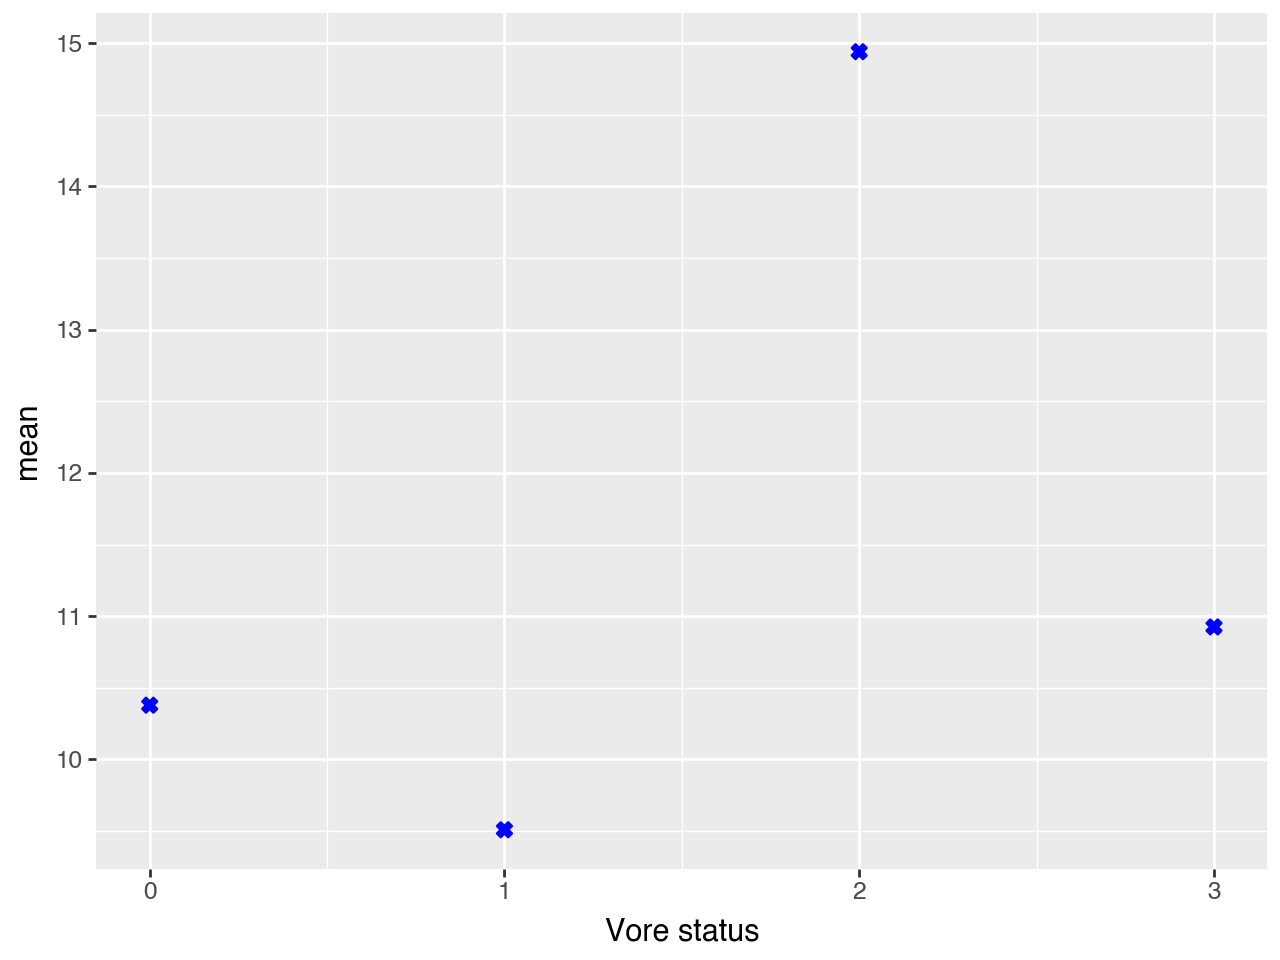

In [35]:
p = (pn.ggplot(data = odf)
    + pn.geom_point(pn.aes(x = "numeric_vore", y = "mean"),
        color = "blue", shape = "X", size = 2.5))
p += pn.labs(x = "Vore status")
p

In [78]:
p = (pn.ggplot(data = odf)
    + pn.geom_point(pn.aes(x = "numeric_vore", y = "mean"),
        color = "blue", shape = "X", size = 2.5))

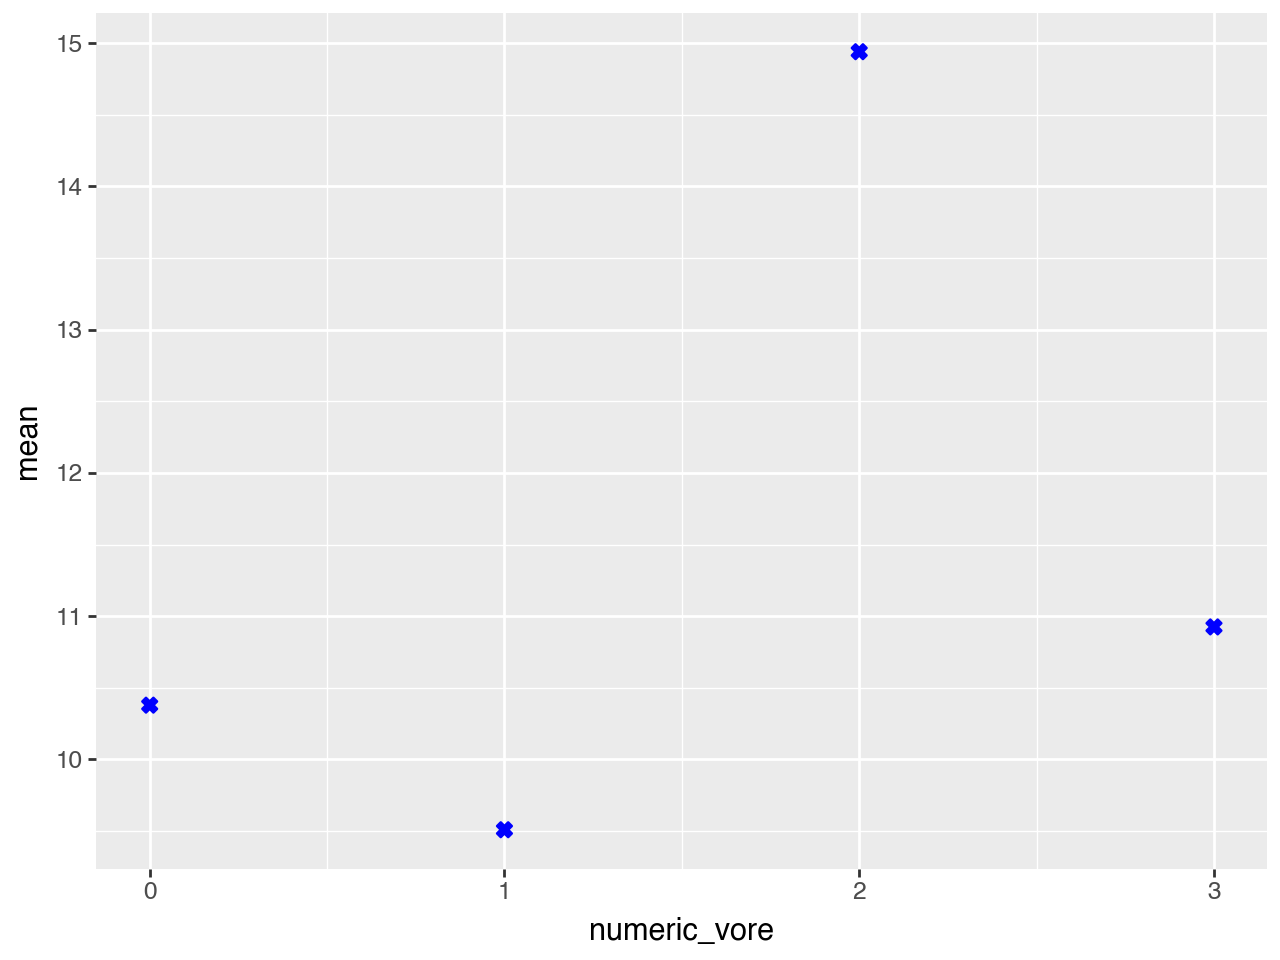

In [79]:
p

In [80]:
p += pn.geom_linerange(pn.aes(x = "numeric_vore", ymin = "lb2", ymax = "ub2")) # 95%
p += pn.geom_linerange(pn.aes(x = "numeric_vore", ymin = "lb1", ymax = "ub1"), size = 1.5) # 68%

In [81]:
p += pn.geom_jitter(df,              # notice the change in dataset
        pn.aes(x = "numeric_vore", y = "sleep_total", color = "vore"),
        width = 0.25,                # the maximal width of horizontal noise/jitter
        alpha = 0.5
)

In [82]:
p += pn.scale_x_continuous(                # continuous x-axis scale based on numeric codes of vore
    breaks = df["numeric_vore"].to_list(), # breaks dictate where on the x-axis, a list of numeric values
    labels = df["vore"].to_list()          # list of labels at breaks
)

In [83]:
p += pn.guides(color = pn.guide_legend(title = "Vore status"))

In [84]:
p += pn.labs(
    x = "Vore status", y = "Sleep (hours)",
    title = "Hours of sleep by vore status"
)

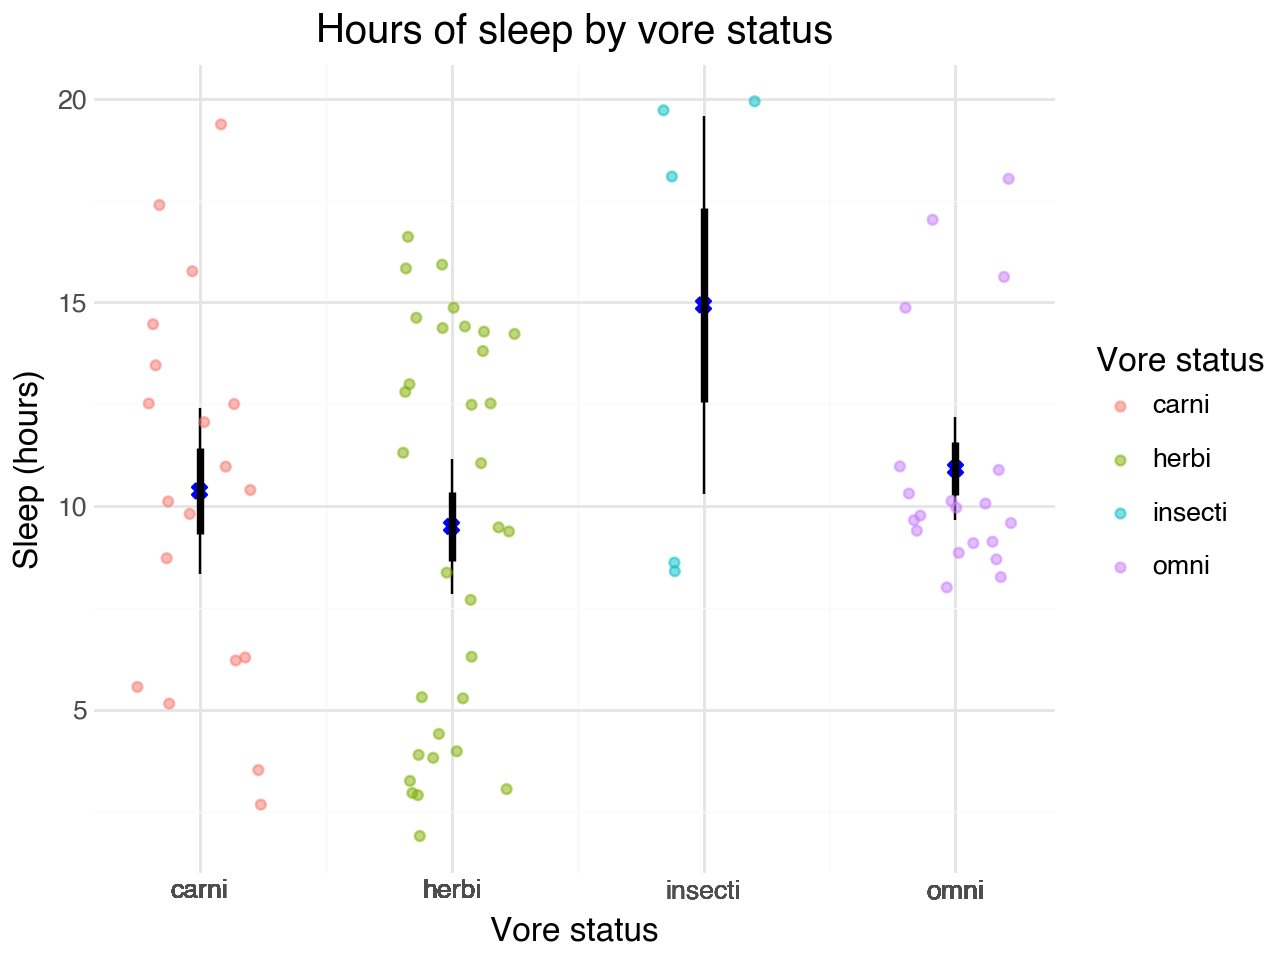

In [85]:
p += pn.theme_minimal(base_size = 12)
p

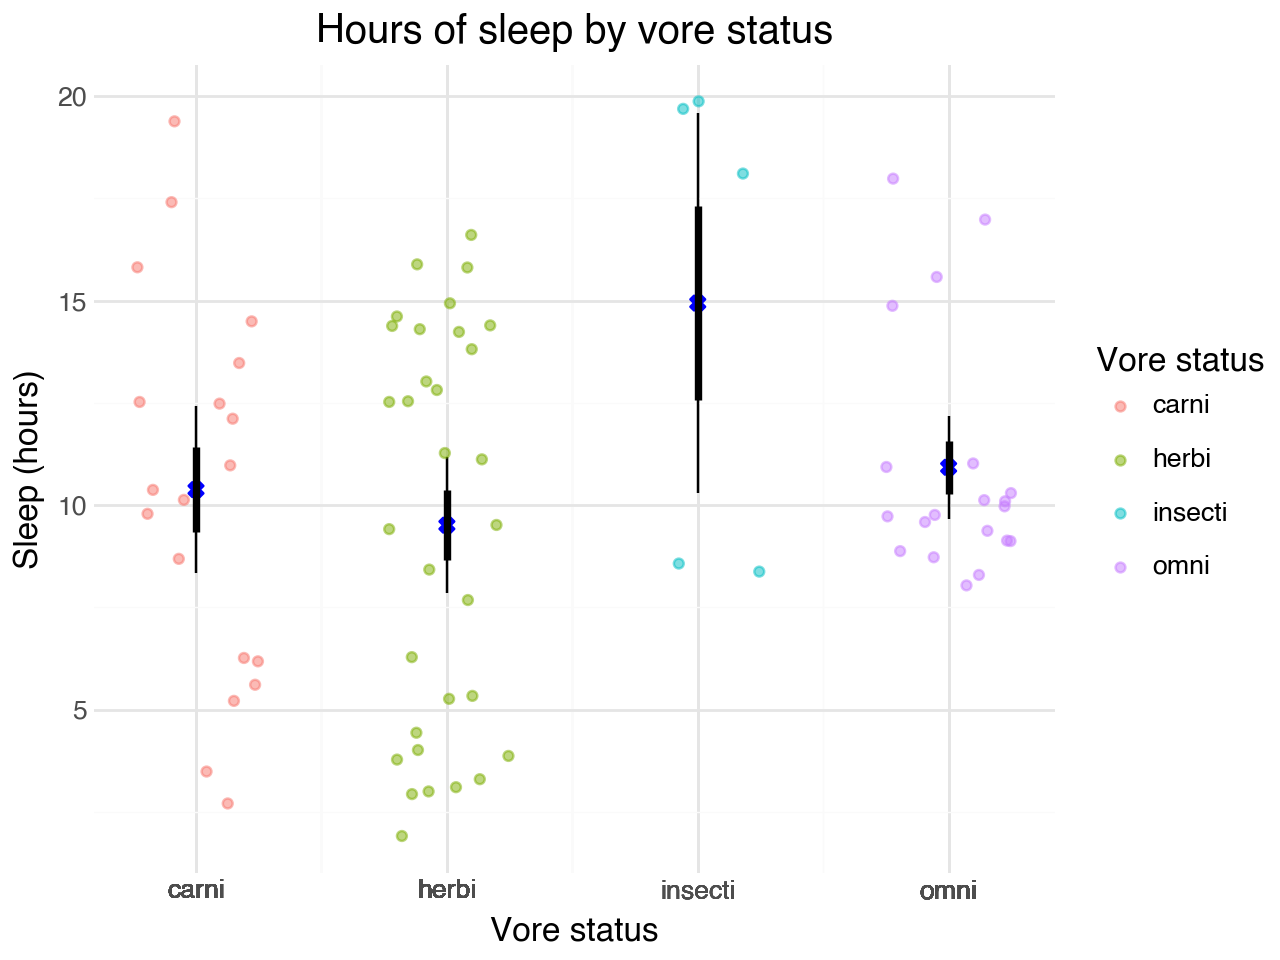

In [86]:
p

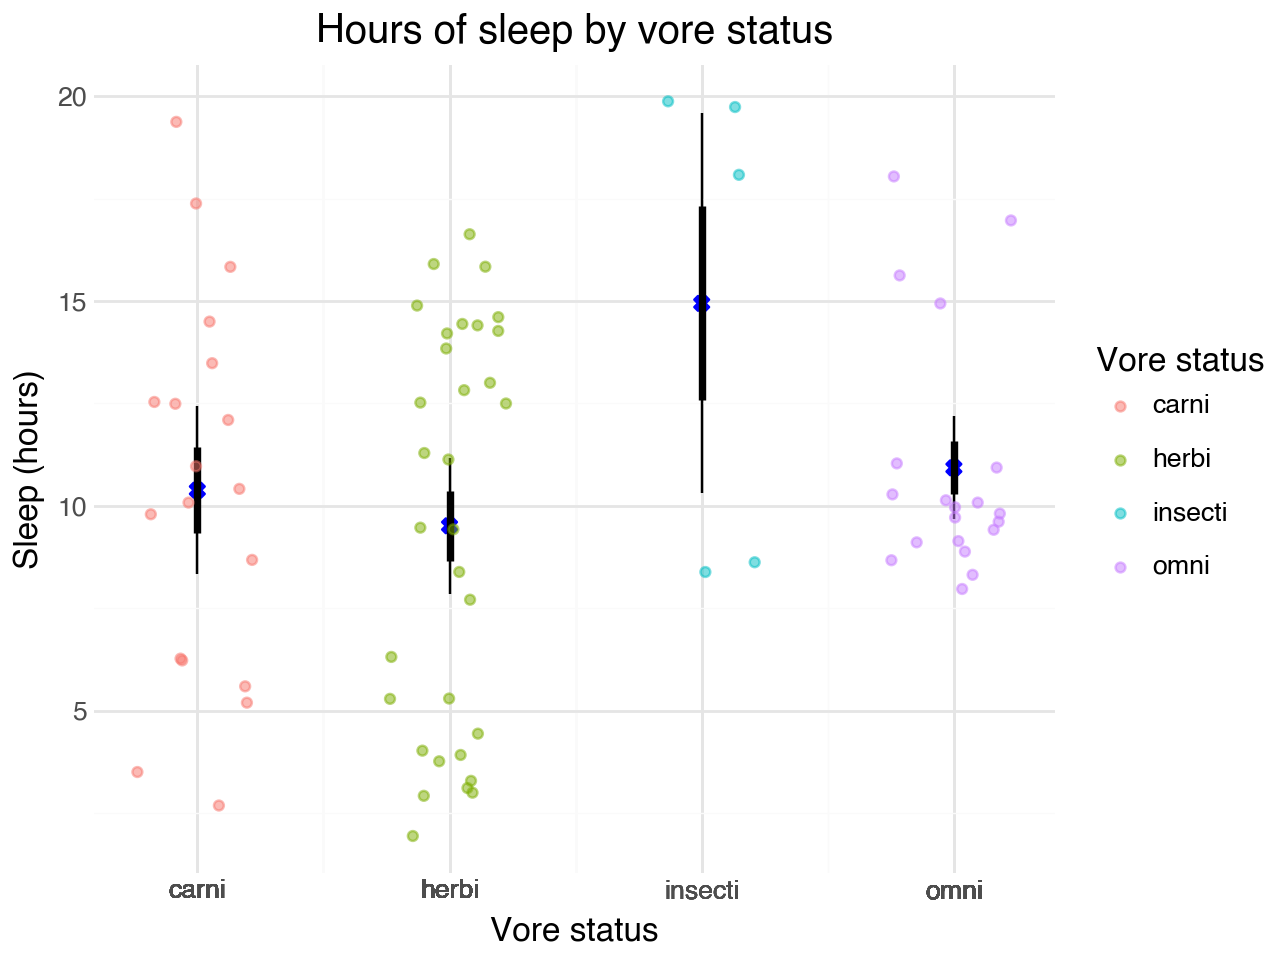

In [87]:
p